In [293]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [294]:
iris = load_iris()

In [295]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                
    :Summary Statistics:

    ============== ==== ==== ======= ===== ====================
                    Min  Max   Mean    SD   Class Correlation
    ============== ==== ==== ======= ===== ====================
    sepal length:   4.3  7.9   5.84   0.83    0.7826
    sepal width:    2.0  4.4   3.05   0.43   -0.4194
    petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
    petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
    ============== ==== ==== ======= ===== ===========

In [296]:
X = iris.data
y = iris.target

In [297]:
print("Feature Names:", iris.feature_names)
print(f"Target Name: {iris.target_names}")

Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target Name: ['setosa' 'versicolor' 'virginica']


In [298]:
# iris.rename(columns= {'sepal length (cm)': 'Sepal_length', 'sepal width (cm)': 'Sepal_width', 'petal length (cm)': 'Petal_length', 'petal width (cm)': 'Petal_width'})

In [299]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [300]:
# Train model
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [301]:
y_pred = model.predict(X_test)

In [ ]:
# Evaluation

print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}\n")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}\n")
print(f"Classification Report:\n{classification_report(y_test, y_pred)}")

Accuracy Score: 1.0

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



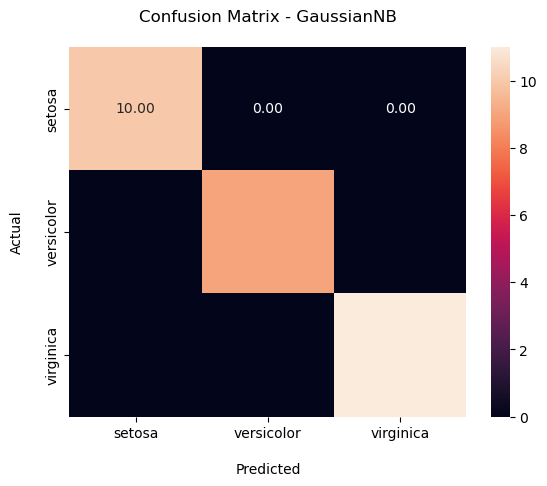

In [303]:
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred), annot= True, fmt= '.2f', xticklabels= iris.target_names, yticklabels= iris.target_names)
plt.title("Confusion Matrix - GaussianNB\n")
plt.xlabel("\nPredicted")
plt.ylabel("Actual\n")
plt.show()

1. we are going to work on spambase dataset, where the normalized frequency of different words in an email are recorded, based on which an email is labeled as spam (1) or not spam (0)

2. Read dataset “spambase.csv”.

3. Split the data into a train and test set.

4. Implement Bagging using Random Forest Algorithm.

5. Implement Boosting using Adaboost Algorithm.

In [304]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [305]:
spam_data = pd.read_csv('./Datasets/spambase.csv')

In [306]:
spam_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_req_our                4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

In [307]:
features = spam_data.columns.drop('spam')
target = 'spam'
X = spam_data[features]
y = spam_data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 100)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3680, 57), (921, 57), (3680,), (921,))

Method 1: Train Random Forest (Bagging)

In [308]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators= 10, min_samples_split=20, min_impurity_decrease= 0.05)
model.fit(X_train, y_train)
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)
print(f"Train accuracy: {train_accuracy}\nTest accuracy: {test_accuracy}")

Train accuracy: 0.842391304347826
Test accuracy: 0.8403908794788274


Method 2: Train AdaBOost (Boosting)

In [309]:
from sklearn.ensemble import AdaBoostClassifier
model = AdaBoostClassifier(n_estimators= 10)
model.fit(X_train, y_train)
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)
print(f"Train accuracy: {train_accuracy}\nTest accuracy: {test_accuracy}")

Train accuracy: 0.9195652173913044
Test accuracy: 0.9272529858849077


In [310]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
print("Accuracy:",accuracy)
print("Classification Report")
print(report)

Accuracy: 0.9272529858849077
Classification Report
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       546
           1       0.94      0.88      0.91       375

    accuracy                           0.93       921
   macro avg       0.93      0.92      0.92       921
weighted avg       0.93      0.93      0.93       921



In [311]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)
print(f"Train accuracy: {train_accuracy}\nTest accuracy: {test_accuracy}")

Train accuracy: 0.9991847826086957
Test accuracy: 0.9153094462540716
